# Support Vector Machine (SVM)

## Introduction

This notebook focuses on building a machine learning model to detect suspicious reviews using a Support Vector Machine (SVM). The goal is to classify reviews as either suspicious or non suspicious based on both textual and behavioural features.

The approach combines TF-IDF representations of review text with engineered features such as review frequency, unverified ratio, and rating patterns. This allows the model to capture both linguistic and behavioural signals associated with suspicious activity.

The model is evaluated using accuracy, F1-score, and recall, and further analysed through misclassification to understand its performance.



In [19]:
# Install necessary libraries
!pip install joblib
!pip install scikit-learn==1.8.0

In [61]:
# Import necessary libraries
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt

import joblib

from scipy.sparse import hstack
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score

## Loading data 


In [45]:
#Load original dataset
df = pd.read_csv("Amazon_reviews_final.csv") 

# Load structured features (from the preprocessing)
X_train = joblib.load("shared_suspicious/X_train_features.pkl")
X_test = joblib.load("shared_suspicious/X_test_features.pkl")

# Load TF-IDF features
X_train_text = joblib.load("shared_suspicious/X_train_text.pkl")
X_test_text = joblib.load("shared_suspicious/X_test_text.pkl")

# Load labels
y_train = joblib.load("shared_suspicious/y_train.pkl")
y_test = joblib.load("shared_suspicious/y_test.pkl")

# load test index
test_index = joblib.load("shared_suspicious/test_indices.pkl")

# TF-IDF
#tfidf = joblib.load("shared_suspicious/tfidf_vectorizer.pkl")



### Load selected features

In [22]:
# from feature ablation
with open("new_features/selected_features.json", "r") as f:
    selected_features = json.load(f)

### Filter selected feature

In [23]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Selected feature shape:", X_train.shape)

Selected feature shape: (661918, 9)


### Combining features 

In [24]:
X_train_combined = hstack([X_train_text, X_train_selected])
X_test_combined = hstack([X_test_text, X_test_selected])

print("Final shape:", X_train_combined.shape)

Final shape: (661918, 5004)


### Define weight and threshold parameters

In [25]:
weight_options = [
    {0:1, 1:1},
    {0:1, 1:2},
    {0:1, 1:3},
    {0:1, 1:4}
]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

### Train and test the model

In [26]:


for weights in weight_options:
    
    print(f"Training with weights: {weights}")
    
    model = LinearSVC(class_weight=weights)
    
    model.fit(X_train_combined, y_train)
    
    print(f"Done training weights: {weights}")
    
    y_scores = model.decision_function(X_test_combined)
    
    for threshold in thresholds:
        
        y_pred = (y_scores > threshold).astype(int)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "weights": weights,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

Training with weights: {0: 1, 1: 1}
Done training weights: {0: 1, 1: 1}
Training with weights: {0: 1, 1: 2}
Done training weights: {0: 1, 1: 2}
Training with weights: {0: 1, 1: 3}
Done training weights: {0: 1, 1: 3}
Training with weights: {0: 1, 1: 4}
Done training weights: {0: 1, 1: 4}


### View the results

In [27]:

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="f1", ascending=False)

results_df.head(10)

,weights,threshold,precision,recall,f1
15,"{0: 1, 1: 4}",0.3,0.437045,0.309482,0.362365
16,"{0: 1, 1: 4}",0.4,0.444797,0.211268,0.286469
10,"{0: 1, 1: 3}",0.3,0.451112,0.186242,0.263640
17,"{0: 1, 1: 4}",0.5,0.459942,0.139336,0.213879
11,"{0: 1, 1: 3}",0.4,0.470138,0.115820,0.185854
18,"{0: 1, 1: 4}",0.6,0.472112,0.089411,0.150349
12,"{0: 1, 1: 3}",0.5,0.486992,0.075327,0.130473
5,"{0: 1, 1: 2}",0.3,0.488064,0.069416,0.121546
19,"{0: 1, 1: 4}",0.7,0.497343,0.058853,0.105251
13,"{0: 1, 1: 3}",0.6,0.500668,0.047158,0.086197


## SVM Results Interpretation

The results show the performance of the SVM model under different class weight configurations and decision thresholds, evaluated using precision, recall, and F1-score for the suspicious class.

The best performing model is achieved with a class weight of {0:1, 1:4} and a threshold of 0.3, producing the highest F1-score (0.36) and the highest recall (0.31). This indicates that increasing the weight of the minority class (suspicious reviews) helps the model identify more suspicious reviews, improving recall.

However, as the decision threshold increases from 0.3 to 0.7, recall consistently decreases while precision increases. 

For example, at threshold 0.3, recall is relatively high (0.31) but precision is lower (0.44). 
By contrast, at threshold 0.7, precision increases to approximately 0.50, but recall drops significantly to around 0.06.

This shows the trade off between precision and recall. Higher thresholds make the model more conservative, reducing false positives but missing more true suspicious cases.

Similarly, reducing the class weight (e.g., from {0:1, 1:4} to {0:1, 1:2}) leads to a noticeable decline in recall and F1-score. 

This suggests that the model becomes less sensitive to the minority class when it is not sufficiently weighted, making it less effective at detecting suspicious reviews.

Overall, the results indicate that both class weighting and threshold selection play a critical role in model performance. Lower thresholds and higher class weights improve recall and overall balance (F1-score), while higher thresholds increase precision at the expense of missing more suspicious cases.

### Pick best weight and threshold combination

In [28]:
best_weights = {0:1, 1:4}
best_threshold = 0.3

### Retrain Final best Model 

In [29]:
final_model = LinearSVC(class_weight=best_weights)

final_model.fit(X_train_combined, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.","{0: 1, 1: 4}"
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the p

### Make final model prediction

In [30]:
# get decision scores
y_scores = final_model.decision_function(X_test_combined)

# apply best threshold
y_pred = (y_scores > best_threshold).astype(int)

### Evaluate

In [31]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Final SVM Results:")
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Final SVM Results:
Accuracy: 0.9476613488034807
F1 Score: 0.36236472060664066
Recall: 0.3094818913480885

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97    157528
           1       0.44      0.31      0.36      7952

    accuracy                           0.95    165480
   macro avg       0.70      0.64      0.67    165480
weighted avg       0.94      0.95      0.94    165480



### Save model and result

In [32]:
os.makedirs("model_suspicious", exist_ok=True)

# save model
joblib.dump(final_model, "model_suspicious/svm_model.pkl")

# save results
results = pd.DataFrame([{
    "model": "SVM",
    "accuracy": accuracy,
    "f1_score": f1,
    "recall": recall
}])

results.to_csv("model_suspicious/svm_results.csv", index=False)

print("Final SVM model and results saved")

Final SVM model and results saved


### Feature Importance

In [33]:
# load tfidf feature names
tfidf = joblib.load("shared_suspicious/tfidf_vectorizer.pkl")
tfidf_features = tfidf.get_feature_names_out()

# structured feature names
structured_features = selected_features

# combine all feature names
all_feature_names = list(tfidf_features) + structured_features

# get coefficients
coefficients = final_model.coef_[0]

# create dataframe
feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

# absolute importance
feature_importance["Abs_Coefficient"] = np.abs(feature_importance["Coefficient"])

# sort
top_features = feature_importance.sort_values(
    by="Abs_Coefficient", ascending=False
)

top_features.head(20)

,Feature,Coefficient,Abs_Coefficient
2858,monotonous,-2.817279,2.817279
1874,generous,-2.598260,2.598260
2467,kennel,-2.579594,2.579594
384,beating,-2.374140,2.374140
4395,tattoo,-2.370610,2.370610
4165,spiritual,-2.271068,2.271068
2831,missile,-2.199046,2.199046
3252,pin,-2.174867,2.174867
3912,security,-2.143898,2.143898
2412,jar,-2.108088,2.108088


Feature importance for the SVM model was analysed using the model coefficients. The magnitude of each coefficient shows how strongly a feature influences the prediction, while the sign indicates its direction.

The results show that several words such as "monotonous", "generous", and "tattoo" had strong influence on the model’s predictions. These features come from the TF-IDF text representation.

However, the model was trained using both text features and structured behavioural features. 

The occurence of word based features in the importance ranking is due to the large number of TF-IDF features compared to the small number of structured features.

This suggests that while text features contribute significantly to the model, they may overshadow important behavioural signals. Overall, combining text and structured features provides a more comprehensive approach to detecting suspicious reviews.

### Misclassification analysis

In [49]:

results_df = pd.DataFrame({
    "text": df.iloc[test_index]["reviewText"].values,
    "true_label": y_test,
    "predicted": y_pred
})

In [50]:
# false positives 
false_positives = results_df[
    (results_df["true_label"] == 0) & (results_df["predicted"] == 1)
]

# false negatives
false_negatives = results_df[
    (results_df["true_label"] == 1) & (results_df["predicted"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 3170
False Negatives: 5491


### False Negatives

In [ ]:
# extract false negative review text
print(false_positives["text"].head(5))

80901     Luckily enough the last (probably) installment...
727995    it's just too bad that Follett felt the need t...
685012    Should a person enjoy anything about history t...
10771     This book is the best book ever. I have read l...
397718    I really enjoyed reading the Hunger Game serie...
Name: text, dtype: object


### False Positives

In [ ]:
# extract False positive review text
print(false_negatives["text"].head(5))

427556    Great book i love...cant wait to read the next...
736199    kept my interest and made me want to keep read...
351482    Watch the movie  and u will be mindblown more ...
264564    Only problem is it does not have a zipper but ...
511752    The pillars of the earth is the best novel I h...
Name: text, dtype: object




False positives were observed in reviews that contained strong or enthusiastic language, such as “great book” and “best novel”. The model incorrectly classified these as suspicious, suggesting that it associates exaggerated or highly positive expressions with suspicious behaviour.

False negatives were reviews that appeared normal and natural, even though they were labelled as suspicious. These reviews did not contain obvious patterns, making them difficult for the model to detect.

Overall, this shows that the SVM model struggles when suspicious reviews are written in a natural way, and when genuine reviews contain strong emotional language.

### short reviews check
Helps confirms:

Are missed reviews short?  
Are they weak signals?

In [53]:
false_negatives["text"].str.len().describe()

count    5491.000000
mean      303.912220
std       579.275661
min         1.000000
25%        66.000000
50%       132.000000
75%       290.000000
max      8714.000000
Name: text, dtype: float64

An analysis of review length shows that most reviews are relatively short, with a median length of 132 words and an average of approximately 304 words. Some reviews are extremely short, consisting of only a few words, while others are significantly longer.

This indicates that short reviews are common in the dataset and are not necessarily indicative of suspicious behaviour. Although very short reviews may lack detail and could be associated with suspicious activity.

### Group suspicious and non suspicious reviews

In [55]:

# create analysis dataframe from structured features
analysis_df = X_test[selected_features].copy()

# add labels
analysis_df["label"] = y_test

# group by label
summary = analysis_df.groupby("label").mean()

summary

,review_frequency,unverified_ratio,extreme_rating_ratio,very_short_review
label,,,,
0,1.604197,0.153302,0.732978,0.440779
1,2.436117,0.778758,0.865437,0.350352


An analysis of the combined effect of the selected features shows clear differences between suspicious and non suspicious reviews.

Suspicious reviews have a significantly higher unverified ratio (0.78 vs 0.15), making it the strongest indicator of suspicious behaviour. They also exhibit higher review frequency and a greater tendency towards extreme ratings.

### verified vs unverifeid reviews

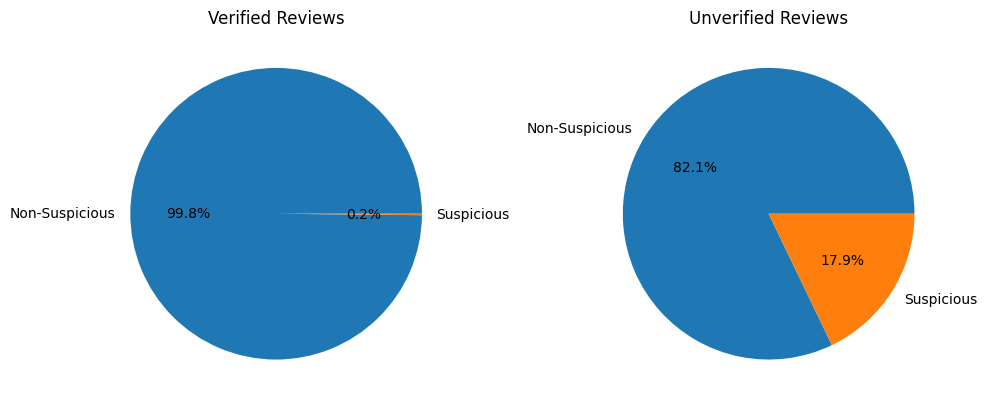

In [ ]:

# prepare dataframe
analysis_df = df.iloc[test_index].copy()
analysis_df["predicted"] = y_pred
analysis_df["verified"] = analysis_df["verified"].astype(int)

# split data
verified = analysis_df[analysis_df["verified"] == 1]
unverified = analysis_df[analysis_df["verified"] == 0]

# counts
verified_counts = verified["predicted"].value_counts().sort_index()
unverified_counts = unverified["predicted"].value_counts().sort_index()

# labels
labels = ["Non-Suspicious", "Suspicious"]

# create figure
plt.figure(figsize=(10,5))

# verified
plt.subplot(1,2,1)
plt.pie(verified_counts, labels=labels, autopct='%1.1f%%')
plt.title("Verified Reviews")

# unverified
plt.subplot(1,2,2)
plt.pie(unverified_counts, labels=labels, autopct='%1.1f%%')
plt.title("Unverified Reviews")

plt.tight_layout()
plt.show()


Among verified reviews, only 0.2% are classified as suspicious, indicating that verified reviews are highly reliable. In contrast, 17.9% of unverified reviews are classified as suspicious, showing a significantly higher likelihood of suspicious behaviour.

However, the majority of unverified reviews (82.1%) are still non suspicious.

#

## Save final Model


In [65]:
# create folder
os.makedirs("model_suspicious", exist_ok=True)

# save svm model and tfidf
joblib.dump(final_model, "model_suspicious/svm_model.pkl")
joblib.dump(tfidf, "model_suspicious/svm_tfidf.pkl")

# evaluation
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# save results
results = pd.DataFrame([{
    "model": "SVM",
    "accuracy": accuracy,
    "f1_score": f1,
    "recall": recall
}])

results.to_csv("model_suspicious/svm_results.csv", index=False)

print("svm model and results saved successfully.")

svm model and results saved successfully.


### Reference/inspiration